In [1]:
# Reference
# https://www.kaggle.com/code/matthewmcnulty/bank-account-fraud

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
input_file = 'data/Base.csv'
df = pd.read_csv(input_file)
df_shape = df.shape
print("Number of rows:", df_shape[0])
print("Number of columns:", df_shape[1])

Number of rows: 1000000
Number of columns: 32


### Exploratory Data Analysis

In [4]:
# Display the first 5 rows of the DataFrame
df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,1,0.9,0.166828,-1,88,50,0.020925,-1.331345,AA,769,...,0,500.0,0,INTERNET,3.888115,windows,0,1,0,7
1,1,0.9,0.296286,-1,144,50,0.005418,-0.816224,AB,366,...,0,1500.0,0,INTERNET,31.798819,windows,0,1,0,7
2,1,0.9,0.044985,-1,132,40,3.108549,-0.755728,AC,870,...,0,200.0,0,INTERNET,4.728705,other,0,1,0,7
3,1,0.9,0.159511,-1,22,50,0.019079,-1.205124,AB,810,...,1,200.0,0,INTERNET,2.047904,linux,0,1,0,7
4,1,0.9,0.596414,-1,218,50,0.004441,-0.773276,AB,890,...,0,1500.0,0,INTERNET,3.775225,macintosh,1,1,0,7


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

In [6]:
df.describe(include=["object", "bool"]).transpose()

,count,unique,top,freq
payment_type,1000000,5,AB,370554
employment_status,1000000,7,CA,730252
housing_status,1000000,7,BC,372143
source,1000000,2,INTERNET,992952
device_os,1000000,5,other,342728


In [7]:
# Target distribution
fraud_vals = pd.DataFrame(df['fraud_bool'].value_counts())
print(fraud_vals)

             count
fraud_bool        
0           988971
1            11029


C:\Users\denni\AppData\Local\Temp\ipykernel_3560\2507604212.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fraud_vals, x="fraud_bool", y="count", palette=my_palette, alpha=.6)


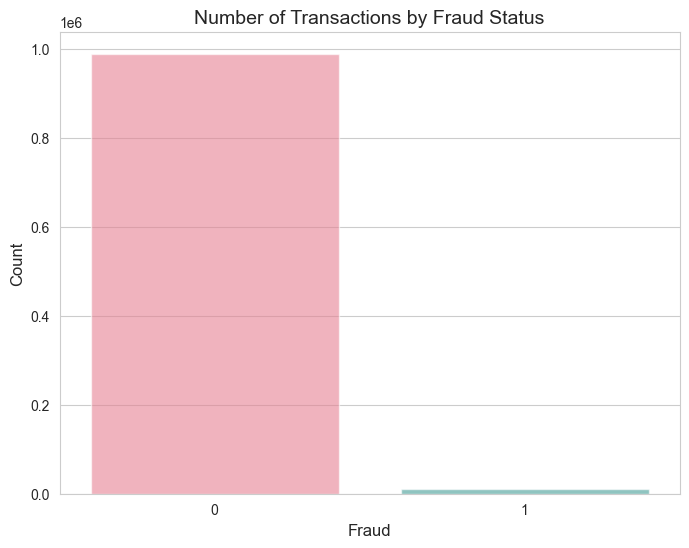

In [8]:
# Define custom color palette
my_palette = sns.color_palette("husl", 2)
sns.set_style("whitegrid")

# Set up plot
plt.figure(figsize=(8, 6))

# Create bar plot
sns.barplot(data=fraud_vals, x="fraud_bool", y="count", palette=my_palette, alpha=.6)

# Customize labels and legend
plt.xlabel("Fraud", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.title("Number of Transactions by Fraud Status", fontsize=14)

# Display plot
plt.show()

# Categorical Variable Encoding

In [9]:
categorical_cols = df.select_dtypes(include = ["object"])

# Payment Type

conditions_list_pt = [
    df["payment_type"] == "AA",
    df["payment_type"] == "AB",
    df["payment_type"] == "AC",
    df["payment_type"] == "AD",
    df["payment_type"] == "AE",
]

choices_list_pt = [0, 1, 2, 3, 4]

df["credit_payment_plan_encoded"] = np.select(conditions_list_pt, choices_list_pt)

# Employment status

conditions_list_es = [
    df["employment_status"] == "Employed_A",
    df["employment_status"] == "Employed_B",
    df["employment_status"] == "Other"
]

choices_list_es = [0, 1, 2]

df["employment_status_encoded"] = np.select(conditions_list_es, choices_list_es)

# Housing 

conditions_list_hs = [
    df["housing_status"] == "other",
    df["housing_status"] == "Owned_or_Rented",
]

choices_list_hs = [0, 1]

df["housing_status_encoded"] = np.select(conditions_list_hs, choices_list_hs)

# source

conditions_list_is = [
    df["housing_status"] == "OTHER",
    df["source"] == "INTERNET",
]

choices_list_is = [0, 1]

df["housing_status_encoded"] = np.select(conditions_list_is, choices_list_is)

# device OS

conditions_list_os = [
    df["device_os"] == "linux",
    df["device_os"] == "macos",
    df["device_os"] == "windows",
    df["device_os"] == "other"
]

choices_list_os = [0, 1, 2, 4]

df["device_status_encoded"] = np.select(conditions_list_os, choices_list_os)



## Categorical variable distributions strata by Target Variable 

In [10]:
def category_histplot(df):

    cat_cols = categorical_cols.columns

    fig, axs = plt.subplots(2, 3, figsize = (14, 12))

    axs = axs.flatten()

    for i, var in enumerate(cat_cols):
        sns.histplot(x = var, 
                data = df, 
                hue = "fraud_bool",
                multiple = "stack",
                discrete= True,
                edgecolor = "black", 
                palette={0: '#3498db', 1: '#e74c3c'},
                ax = axs[i])
        
        for container in axs[i].containers:
            axs[i].bar_label(container, fmt = "%d", label_type = "edge", fontsize = 7)

        unique_vals = sorted(df[var].unique())
        axs[i].set_xticks(unique_vals)
        axs[i].set_xticklabels(unique_vals)

        axs[i].set_title(f"Distribution of {var.capitalize()} by Target", fontsize = 12, fontweight = "bold")
        axs[i].set_xlabel(f"{var.capitalize()}", fontsize = 12)
        axs[i].set_ylabel(f"Count", fontsize = 12)
        axs[i].legend(labels=["Fraud", "Not Fraudulent"], 
                      title="Target", 
                      fontsize=6)


    fig.delaxes(axs[5])
    plt.tight_layout()
    plt.show()

In [11]:
# Missing values
missing = df.isnull().sum()
if missing.sum() > 0:
    missing_df = pd.DataFrame({
        'Column': missing[missing > 0].index,
        'Missing': missing[missing > 0].values,
        'Percentage': 100 * missing[missing > 0].values / len(df)
    })
    print(missing_df.to_string(index=False))
else:
    print("No missing values!")

No missing values!


In [12]:
# Initialize an empty DataFrame to hold the percentage of missing values for each feature
missing_vals = pd.DataFrame()

# List of features to check for missing values
missing_features = ['prev_address_months_count', 'current_address_months_count', 'intended_balcon_amount', 'bank_months_count', 'session_length_in_minutes', 'device_distinct_emails_8w']

# For each feature, replace -1 values with NaN, calculate the percentage of missing values, and add to the missing_vals DataFrame
for feature in missing_features:
    df.loc[df[feature] < 0, feature] = np.nan # df[feature] = df[feature].replace(-1, np.nan)
    missing_vals_col = df.groupby('fraud_bool')[feature].apply(lambda x: round(x.isna().sum()/len(x) * 100, 2))
    missing_vals[feature] = missing_vals_col

print(missing_vals)

            prev_address_months_count  current_address_months_count  \
fraud_bool                                                            
0                               71.06                          0.43   
1                               91.89                          0.13   

            intended_balcon_amount  bank_months_count  \
fraud_bool                                              
0                            74.09              25.23   
1                            88.38              37.54   

            session_length_in_minutes  device_distinct_emails_8w  
fraud_bool                                                        
0                                0.20                       0.04  
1                                0.16                       0.04  


In [13]:
# Reshape the missing_vals DataFrame from wide to long format
missing_vals = pd.DataFrame(missing_vals.T.stack())

# Reset the index and rename the columns
missing_vals.reset_index(inplace=True)
missing_vals.rename(columns={'level_0': 'feature', 0: 'missing_vals'}, inplace=True)

print(missing_vals)

                         feature  fraud_bool  missing_vals
0      prev_address_months_count           0         71.06
1      prev_address_months_count           1         91.89
2   current_address_months_count           0          0.43
3   current_address_months_count           1          0.13
4         intended_balcon_amount           0         74.09
5         intended_balcon_amount           1         88.38
6              bank_months_count           0         25.23
7              bank_months_count           1         37.54
8      session_length_in_minutes           0          0.20
9      session_length_in_minutes           1          0.16
10     device_distinct_emails_8w           0          0.04
11     device_distinct_emails_8w           1          0.04


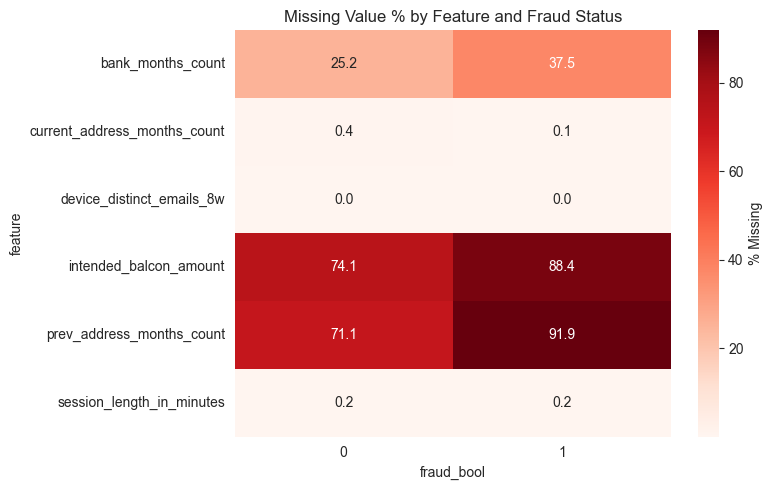

In [14]:
heatmap_data = missing_vals.pivot(
    index='feature',        # y 軸
    columns='fraud_bool',   # x 軸
    values='missing_vals'   # 格子裡的數值
)
plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_data,
    annot=True,        
    fmt='.1f',
    cmap='Reds',
    cbar_kws={'label': '% Missing'}
)

plt.title('Missing Value % by Feature and Fraud Status')
plt.xlabel('fraud_bool')
plt.ylabel('feature')
plt.tight_layout()
plt.show()

In [15]:
numeric_cols = df.select_dtypes(include=np.number)
numeric_cols

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,...,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month,credit_payment_plan_encoded,employment_status_encoded,housing_status_encoded,device_status_encoded
0,1,0.9,0.166828,NaN,88.0,50,0.020925,NaN,769,10650.765523,...,0,3.888115,0,1.0,0,7,0,0,1,2
1,1,0.9,0.296286,NaN,144.0,50,0.005418,NaN,366,534.047319,...,0,31.798819,0,1.0,0,7,1,0,1,2
2,1,0.9,0.044985,NaN,132.0,40,3.108549,NaN,870,4048.534263,...,0,4.728705,0,1.0,0,7,2,0,1,4
3,1,0.9,0.159511,NaN,22.0,50,0.019079,NaN,810,3457.064063,...,0,2.047904,0,1.0,0,7,1,0,1,0
4,1,0.9,0.596414,NaN,218.0,50,0.004441,NaN,890,5020.341679,...,0,3.775225,1,1.0,0,7,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0,0.6,0.192631,NaN,104.0,40,0.030592,NaN,804,7905.711839,...,0,8.511502,1,1.0,0,4,1,0,1,0
999996,0,0.8,0.322989,148.0,9.0,50,1.628119,NaN,3306,5391.470463,...,0,8.967865,0,1.0,0,4,2,0,1,2
999997,0,0.8,0.879403,NaN,30.0,20,0.018563,34.692760,1522,8063.102636,...,0,8.195531,0,1.0,0,4,0,0,1,4
999998,0,0.9,0.762112,NaN,189.0,20,0.015352,94.661055,1418,8092.641762,...,0,4.336064,1,1.0,0,4,0,0,1,2


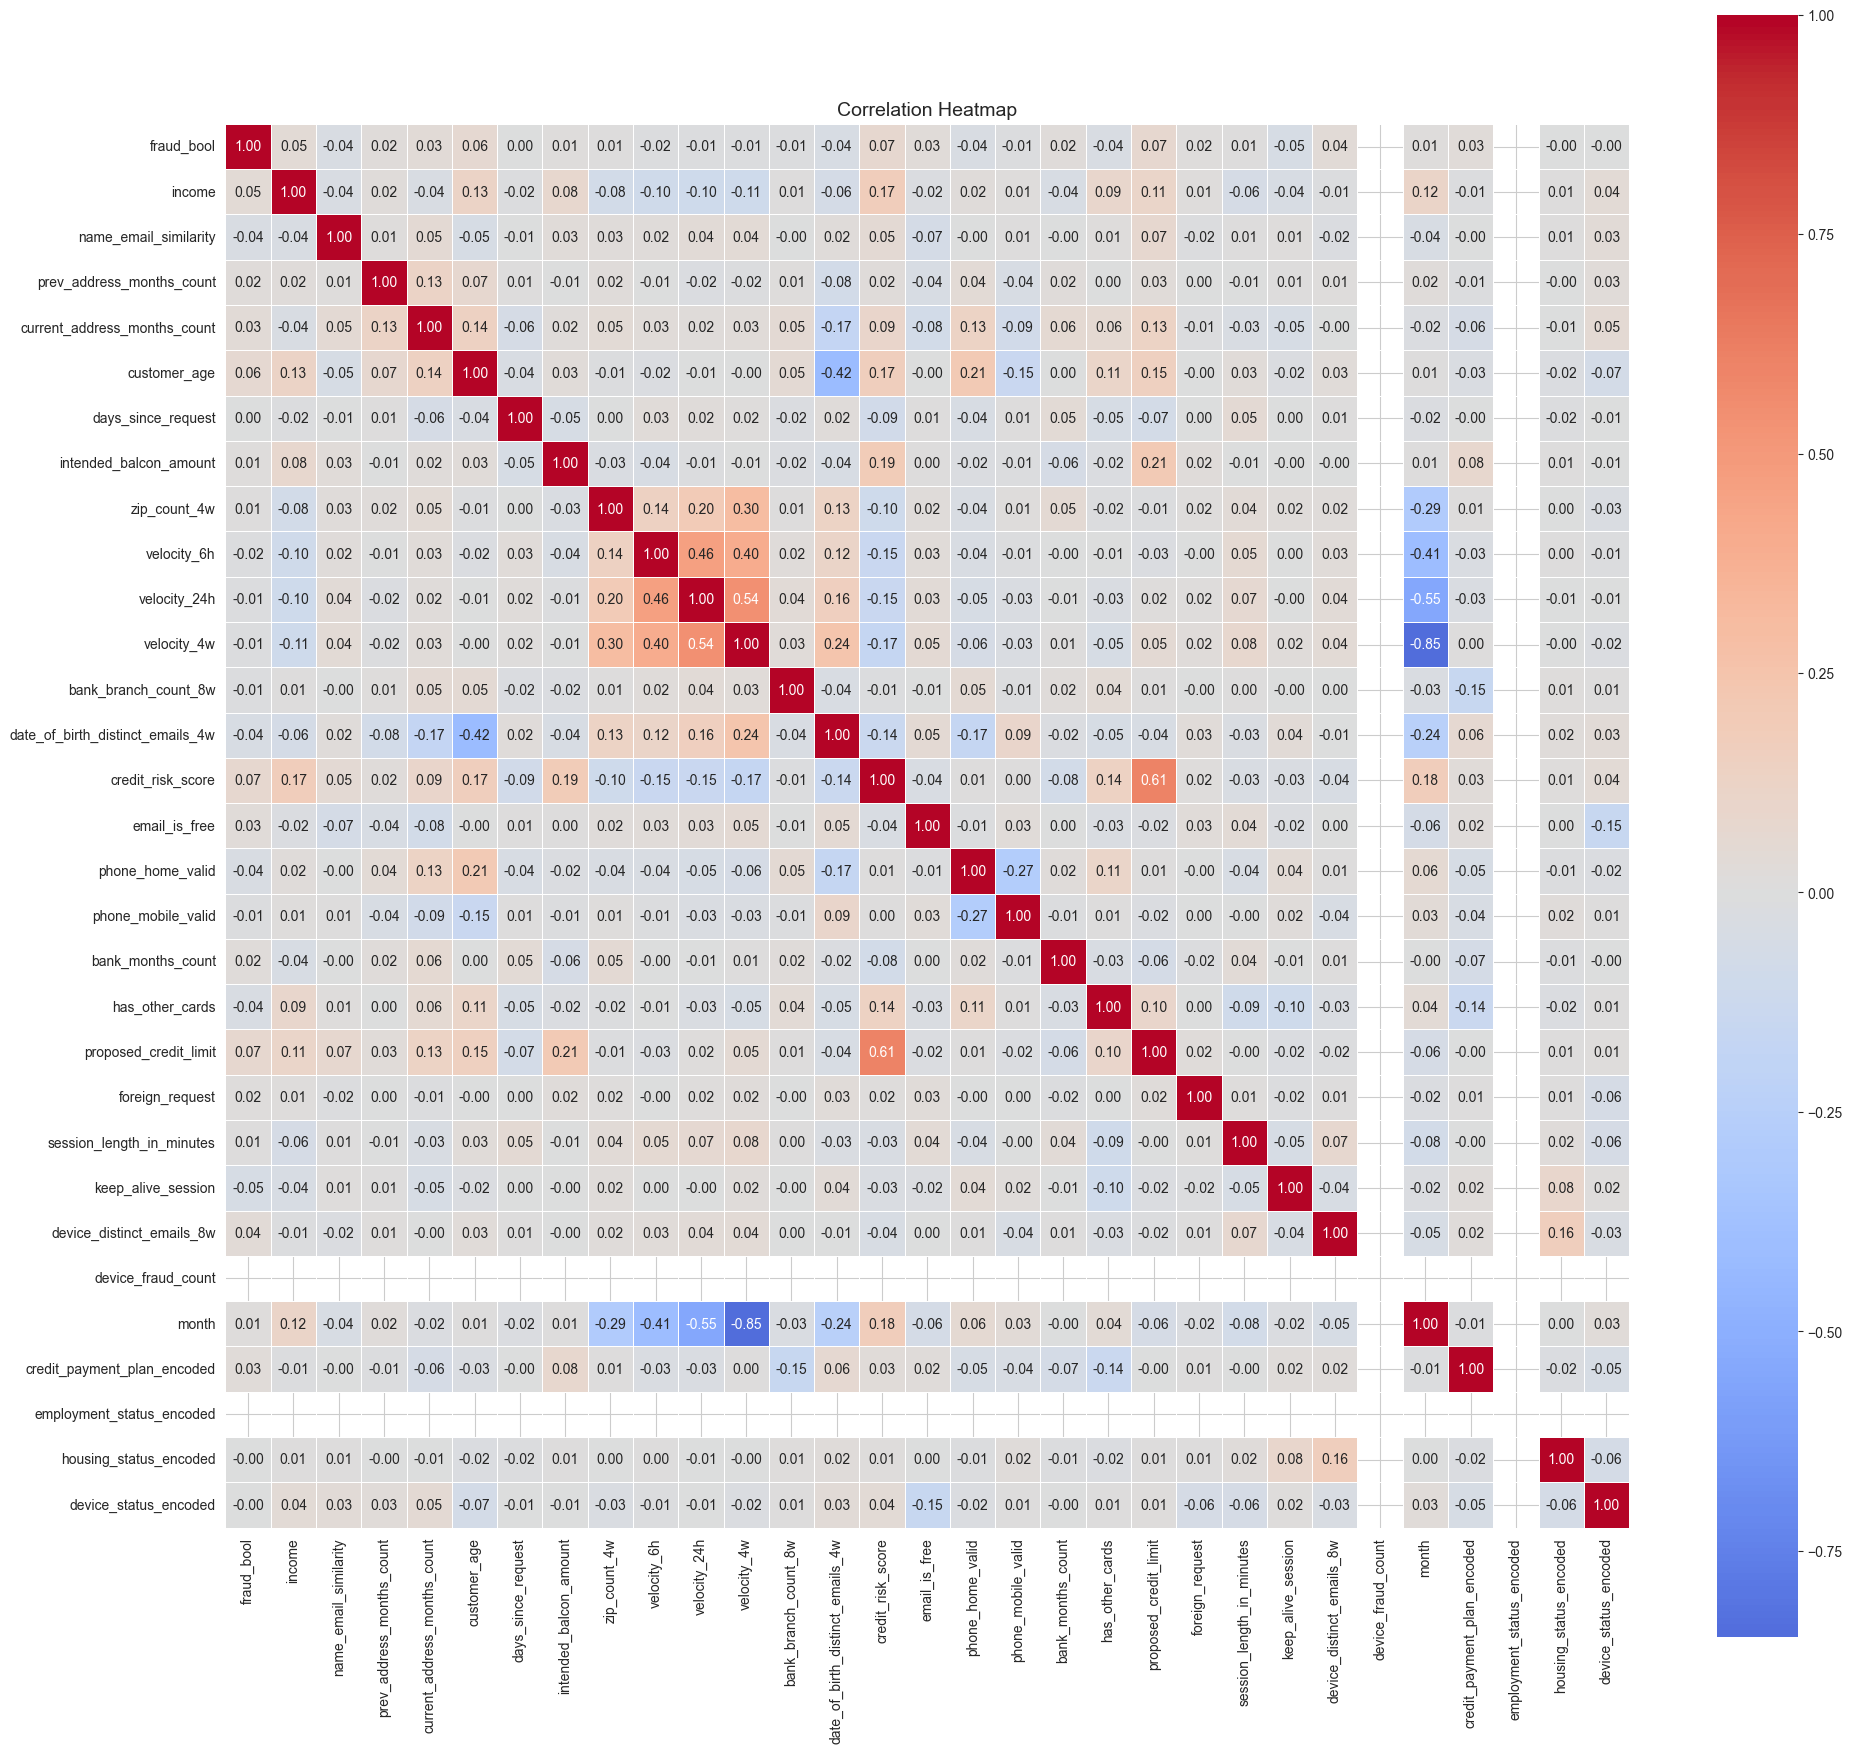

In [16]:
correlation_matrix = numeric_cols.corr()
plt.figure(figsize=(20, 18))  
sns.heatmap(correlation_matrix, 
            annot=True,           
            cmap='coolwarm',     
            center=0,            
            fmt='.2f',            
            square=True,         
            linewidths=0.5)   
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()

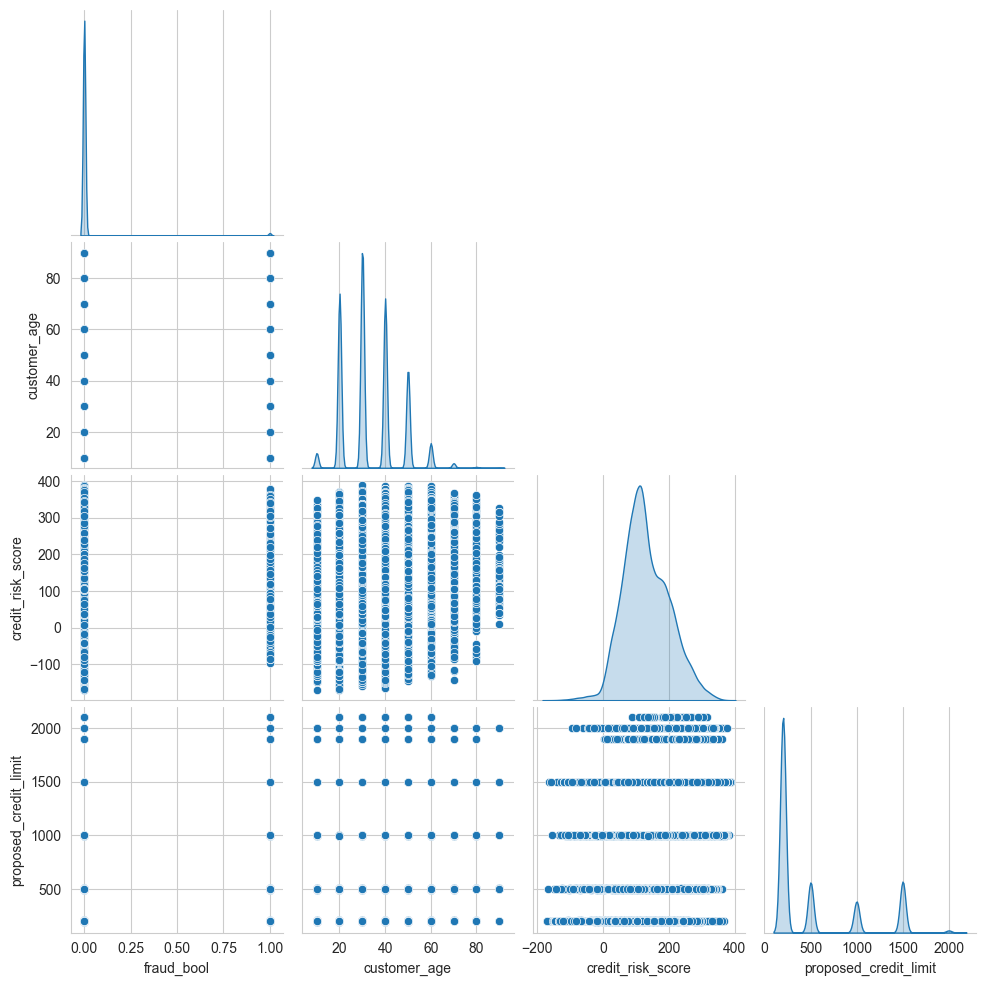

In [17]:
want_to_see_column = numeric_cols[['fraud_bool', 'customer_age','credit_risk_score','proposed_credit_limit']]
sns.pairplot(want_to_see_column, diag_kind='kde', corner=True)